# Lab: Hàm chi phí 
<figure>
    <center> <img src="./images/C1_W1_L3_S2_Lecture_b.png"  style="width:1000px;height:200px;" ></center>
</figure>

## Mục tiêu
Trong lab này, bạn sẽ triển khai và khám phá hàm `cost` cho linear regression với một biến.

## Công cụ
Trong lab này, chúng ta sẽ sử dụng: 
- NumPy, thư viện phổ biến dành cho máy tính khoa học
- Matplotlib, một thư viện phổ biến để vẽ dữ liệu
- Quy trình vẽ đồ thị cục bộ trong file lab_utils_uni.py trong folder cục bộ

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl
plt.style.use('./deeplearning.mplstyle')

## Bài toán

Bạn muốn một mô hình có thể dự đoán giá nhà đất dựa trên quy mô của ngôi nhà.  
Hãy sử dụng hai điểm dữ liệu giống như lab trước - một ngôi nhà rộng 1000 mét vuông được bán với giá $300,000 và một ngôi nhà rộng 2000 mét vuông được bán với giá $500.000.

| Kích thước (1000 mét vuông) | Giá (1000 đô la) |
| -------------------| ------------------------ |
| 1 | 300 |
| 2 | 500 |

In [2]:
x_train = np.array([1.0, 2.0])           #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])           #(price in 1000s of dollars)

## Tính toán cost
Thuật ngữ 'cost' trong bài tập này có thể hơi khó hiểu vì dữ liệu là price nhà ở. Ở đây, cost là thước đo mức độ dự đoán giá target của ngôi nhà mà mô hình của chúng ta dự đoán. Thuật ngữ 'price' được sử dụng cho dữ liệu nhà ở.

Hàm cost với một biến là:
  $$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{1}$$ 
 
ở đây 
  $$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{2}$$
  
- $f_{w,b}(x^{(i)})$ là dự đoán của chúng ta, $i$ example sử dụng tham số $w,b$.  
- $(f_{w,b}(x^{(i)}) -y^{(i)})^2$ là chênh lệch bình phương giữa giá trị target và giá trị dự đoán.   
- Những khác biệt này được tổng hợp trên tất cả các example $m$ và chia cho `2m` để tạo ra cost, $J(w,b)$.  
>Lưu ý, trong phạm vi tổng kết bài giảng thường từ 1 đến m, trong khi code sẽ từ 0 đến m-1.


Code bên dưới tính toán cost bằng cách lặp qua từng example. Trong mỗi vòng lặp:
- `f_wb`, dự đoán được tính toán
- Sự khác biệt giữa target và dự đoán được tính toán và bình phương.
- Điều này được thêm vào tổng cost.


In [3]:
def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # Số training example
    m = x.shape[0] 
    
    cost_sum = 0 
    for i in range(m): 
        f_wb = w * x[i] + b   
        cost = (f_wb - y[i]) ** 2  
        cost_sum = cost_sum + cost  
    total_cost = (1 / (2 * m)) * cost_sum  

    return total_cost

## Trực quan về hàm cost


<img align="left" src="./images/C1_W1_Lab02_GoalOfRegression.PNG"    style=" width:380px; padding: 10px;  " /> Mục tiêu của bạn là tìm một mô hình $f_{w,b}(x) = wx + b$, với các tham số $w,b$, sẽ dự đoán chính xác các giá trị ngôi nhà với đầu vào $x$. Cost là thước đo mức độ chính xác của mô hình trên dữ liệu training.

Hàm cost (1) ở trên cho thấy rằng nếu có thể chọn $w$ và $b$ sao cho dự đoán $f_{w,b}(x)$ khớp với dữ liệu target $y$, thì số hạng $(f_{w,b}(x^{(i)}) - y^{(i)})^2 $ sẽ bằng 0 và cost được giảm thiểu. Trong ví dụ hai điểm đơn giản này, bạn có thể đạt được điều này!

Trong lab trước, bạn đã xác định rằng $b=100$ cung cấp giải pháp tối ưu vì vậy hãy đặt $b$ thành 100 và tập trung vào $w$.

<br/>
Bên dưới, hãy sử dụng thanh trượt để chọn giá trị w nhằm giảm thiểu cost. Có thể mất vài giây để cập nhật plot.


In [ ]:
plt_intuition(x_train,y_train) # Chạy rất lâu

Plot có một số điểm đáng nói.
- Cost được giảm thiểu khi $w = 200$, phù hợp với kết quả từ lab trước
- Vì chênh lệch giữa target và target được bình phương trong phương trình cost nên cost tăng nhanh khi $w$ quá lớn hoặc quá nhỏ.
- Sử dụng `w` và `b` được chọn bằng cách giảm thiểu cost sẽ tạo ra một đường thẳng hoàn toàn phù hợp với dữ liệu.


## Trực quan hóa hàm cost - 3D

Bạn có thể thấy cost thay đổi như thế nào đối với *cả hai* `w` và `b` bằng cách vẽ đồ thị ở dạng 3D hoặc sử dụng đồ thị đường viền.   
Điều đáng chú ý là một số nội dung trong khóa học này có thể khá phức tạp. Các quy trình vẽ đồ thị được cung cấp và mặc dù có thể hướng dẫn bạn đọc qua code để làm quen với các phương pháp nhưng không cần thiết phải hoàn thành khóa học một cách thành công. Các quy trình nằm trong lab_utils_uni.py trong folder cục bộ.


### Tập dữ liệu lớn hơn
Nó mang tính hướng dẫn để xem một kịch bản có thêm một vài điểm dữ liệu. Tập dữ liệu này bao gồm các điểm dữ liệu không nằm trên cùng một đường thẳng. Điều đó có ý nghĩa gì đối với hàm cost? Chúng ta có thể tìm thấy $w$ và $b$ sẽ mang lại cho chúng ta cost bằng 0 không?

In [ ]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480, 430, 630, 730,])

Trong biểu đồ đường viền, nhấp vào một điểm để chọn `w` và `b` để đạt được chi phí thấp nhất. Sử dụng các đường viền để hướng dẫn các lựa chọn của bạn. Lưu ý, có thể mất vài giây để cập nhật biểu đồ.


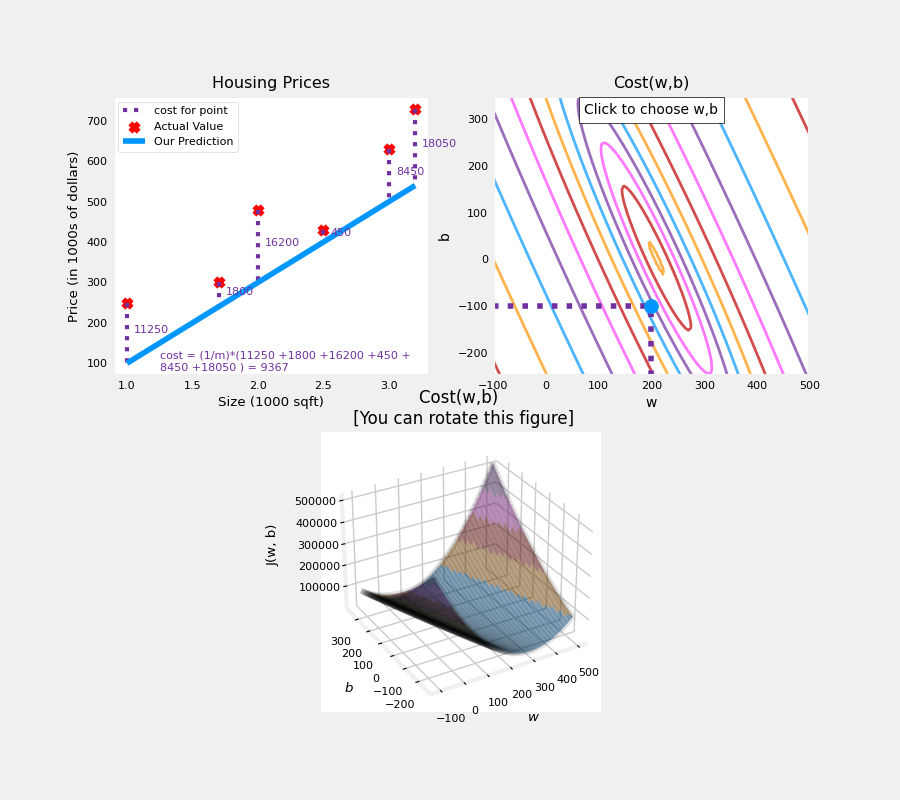

In [5]:
plt.close('all') 
fig, ax, dyn_items = plt_stationary(x_train, y_train)
updater = plt_update_onclick(fig, ax, x_train, y_train, dyn_items)

Ở trên, lưu ý các đường đứt nét ở ô bên trái. Chúng thể hiện phần cost do mỗi ví dụ trong tập training của bạn đóng góp. Trong trường hợp này, các giá trị xấp xỉ $w=209$ và $b=2.4$ mang lại cost thấp. Lưu ý rằng, vì các traning example của chúng ta không nằm trên một đường thẳng nên cost tối thiểu không bằng 0.


### Bề mặt cost lồi
Thực tế là hàm cost bình phương tổn thất đảm bảo rằng 'bề mặt sai số' lồi lên như một cái tô súp. Nó sẽ luôn có mức tối thiểu có thể đạt được bằng cách tuân theo độ dốc ở tất cả các chiều. Trong biểu đồ trước, vì kích thước $w$ và $b$ có tỷ lệ khác nhau nên không dễ nhận ra điều này. Đồ thị sau đây, trong đó $w$ và $b$ đối xứng, đã được trình bày trong bài giảng:


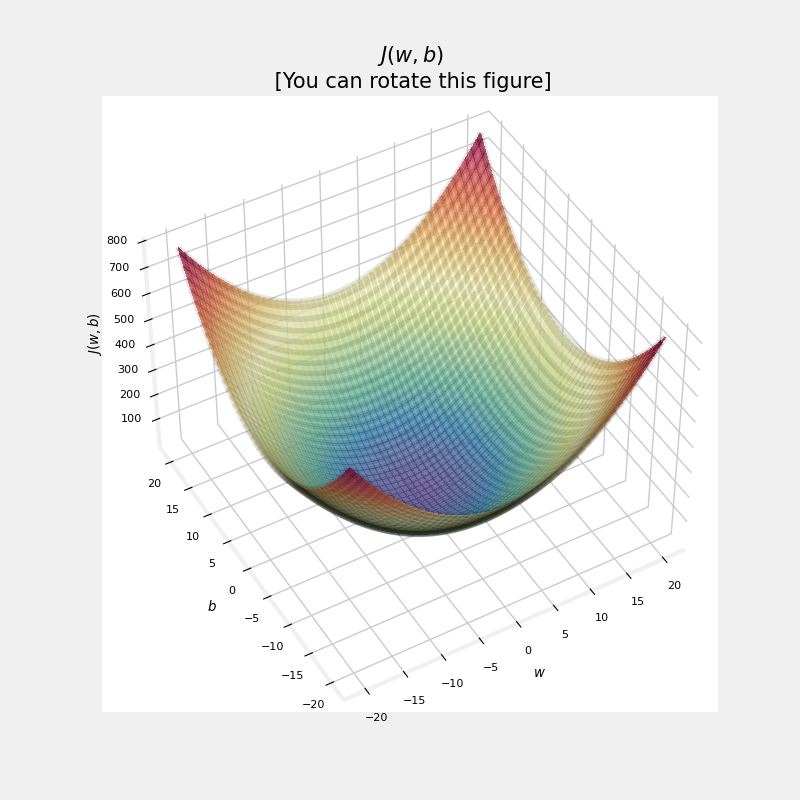

In [8]:
soup_bowl()

# Chúc mừng!
Bạn đã học được những điều sau:
 - Phương trình chi phí cung cấp thước đo mức độ dự đoán của bạn phù hợp với dữ liệu training của bạn như thế nào.
 - Giảm thiểu chi phí có thể mang lại các giá trị tối ưu $w$, $b$.
